In [1]:
import json
import math
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# LOAD DATA + COMPUTE PASS@K
RESULT_FILES = {
    # "Uniform": Path("../../data/results/uniform_vllm/mlvu/cot/f64/Qwen3-VL-4B-Thinking/agent_results.json"),
    # "Qwen 4B Thinking": Path("../../data/results/uniform_vllm/mlvu/cot/f64/Qwen3-VL-4B-Thinking/agent_results.json"),
    # "Qwen 4B Instruct": Path("../../results/uniform_vllm/mlvu/base/f64/Qwen3-VL-8B-Instruct/agent_results.json"),
    #"Qwen 8B Thinking": Path("../../results/uniform_vllm/mlvu/cot/f64/Qwen3-VL-8B-Thinking/agent_results.json"),
    # "Qwen 8B Instruct": Path("../../results/uniform_vllm/mlvu/base/f64/Qwen3-VL-8B-Instruct/agent_results.json"),
    # "Uniform Gemma 12B": Path("../../results/uniform_vllm/mlvu/base/f32/gemma-3-12b-it/agent_results.json"),
    # "Uniform Instruct": Path("../../data/results/uniform_vllm/mlvu/base/f64/Qwen3-VL-4B-Instruct/agent_results.json"),
    # # "VSeek-Base": Path("../../results/vseek/Qwen3-VL-4B-Thinking/mlvu/agent_results.jsonl"),
    # "VSeek-EM": Path("../../results/vseek/vseek/mlvu/agent_results.jsonl"),
    # "VSeek-Puls": Path("../../results/vseek/vseek-puls/mlvu/agent_results.jsonl"),
    # "VSeek-EM-RLOO": Path("../../results/vseek/vseek-rloo/mlvu/agent_results.jsonl"),
    # "VSeek-Puls-RLOO": Path("../../results/vseek/vseek-rloo-puls/mlvu/agent_results.jsonl"),
    # "VSeek-EM-GSPO": Path("../../results/vseek/vseek-gspo/mlvu/agent_results.jsonl"),
    # "VSeek-Puls-GSPO": Path("../../results/vseek/vseek-gspo-puls/mlvu/agent_results.jsonl"),
    # "VSeek-Inst-EM": Path("../../results/vseek/vseek-inst/mlvu/agent_results.jsonl"),
    # "VSeek-Inst-Puls": Path("../../results/vseek/vseek-inst-puls/mlvu/agent_results.jsonl"),
    # "VSeek-Inst-EM-RLOO": Path("../../results/vseek/vseek-inst-rloo/mlvu/agent_results.jsonl"),
    # "VSeek-Inst-Puls-RLOO": Path("../../results/vseek/vseek-inst-puls-rloo/mlvu/agent_results.jsonl"),
    # "VSeek-Inst-GSPO": Path("../../results/vseek/vseek-inst-gspo/mlvu/agent_results.jsonl"),
    # "VSeek-Inst-GSPO-Puls": Path("../../results/vseek/vseek-inst-puls-gspo/mlvu/agent_results.jsonl"),
    "VSeek-Inst-Direct": Path("../../results/vseek/vseek-inst-direct/mlvu/agent_results.jsonl"),
    "VSeek-Direct": Path("../../results/vseek/vseek-direct/mlvu/agent_results.jsonl"),
    # # # "Vanilla RAG": Path("../../results/videorag_vllm/mlvu/cot/f64/Qwen3-VL-4B-Thinking/agent_results.json"),
    # "GPT": Path("../../results/gpt64/mlvu/agent_results.json"),
    # "VSeek-GPT": Path("../../results/vseek/gpt2/mlvu/agent_results.json"),
}
datasets = [ "lvb", "videomme", "mlvu", "lvbench", "cgbench"]



def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

def load_json(path: Path) -> pd.DataFrame:
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    return pd.DataFrame(data)

# Methods that often need prediction re-parsing from raw text.
FORCE_REPARSE_METHODS = {
    "Uniform InternVL 4B",
    "Uniform InternVL 14B",
    "Uniform Gemma 12B",
}

def _choice_token_to_label(token: str) -> str | None:
    if token is None:
        return None
    t = str(token).strip()
    if not t:
        return None
    if t.isdigit():
        return str(int(t))
    if len(t) == 1 and t.upper() in "ABCDEF":
        return str(ord(t.upper()) - ord("A"))
    return None

def parse_choice_label(pred) -> str | None:
    import re
    if pred is None:
        return None
    s = str(pred).strip()
    if not s:
        return None

    # \boxed{...} patterns
    boxed = re.search(r"\\boxed\{([^{}]+)\}", s)
    if boxed:
        lab = _choice_token_to_label(boxed.group(1))
        if lab is not None:
            return lab

    # Explicit answer markers, e.g., "Answer: 3" or "answer is B"
    for pat in [
        r"(?i)\banswer\s*(?:is|:)?\s*([A-F]|\d{1,2})\b",
        r"(?i)\boption\s*([A-F]|\d{1,2})\b",
        r"(?i)\bchoice\s*([A-F]|\d{1,2})\b",
    ]:
        m = re.search(pat, s)
        if m:
            lab = _choice_token_to_label(m.group(1))
            if lab is not None:
                return lab

    # Leading token forms: "3.", "(B)", "A:", etc.
    m = re.match(r"^\s*[\(\[]?\s*([A-F]|\d{1,2})\s*[\)\].,:\-\s]", s)
    if m:
        lab = _choice_token_to_label(m.group(1))
        if lab is not None:
            return lab

    # Entire string is a bare token.
    lab = _choice_token_to_label(s)
    if lab is not None:
        return lab

    return None

def majority_vote_from_labels(labels: list[str]) -> str | None:
    labels = [x for x in labels if x is not None and str(x).strip() != ""]
    if not labels:
        return None
    counts: dict[str, int] = {}
    for x in labels:
        counts[str(x)] = counts.get(str(x), 0) + 1
    return max(counts.items(), key=lambda kv: kv[1])[0]

def maybe_repair_dataframe_predictions(df: pd.DataFrame, method_name: str) -> pd.DataFrame:
    if method_name not in FORCE_REPARSE_METHODS:
        return df

    out = df.copy()

    def _row_labels(row: pd.Series) -> list[str]:
        raw_preds = None
        if "all_preds" in row and isinstance(row["all_preds"], list):
            raw_preds = row["all_preds"]
        elif "pred" in row and isinstance(row["pred"], list):
            raw_preds = row["pred"]
        elif "parsed_pred" in row and isinstance(row["parsed_pred"], list):
            raw_preds = row["parsed_pred"]
        elif "all_parsed_preds" in row and isinstance(row["all_parsed_preds"], list):
            raw_preds = row["all_parsed_preds"]
        else:
            raw_preds = []

        labels = []
        for p in raw_preds:
            lab = parse_choice_label(p)
            labels.append(lab if lab is not None else "")
        return labels

    out["all_parsed_preds"] = out.apply(_row_labels, axis=1)
    out["parsed_pred"] = out["all_parsed_preds"]
    out["majority_vote"] = out["all_parsed_preds"].apply(majority_vote_from_labels)

    if "gt" in out.columns:
        out["gt"] = out["gt"].map(lambda v: _choice_token_to_label(v) if _choice_token_to_label(v) is not None else str(v))
        out["correct_count"] = out.apply(
            lambda r: sum(1 for p in r["all_parsed_preds"] if str(p) == str(r["gt"])),
            axis=1,
        )
        out["is_majority_correct"] = out.apply(
            lambda r: int((r["majority_vote"] is not None) and str(r["majority_vote"]) == str(r["gt"])),
            axis=1,
        )

    return out

def infer_total_passes(row: pd.Series) -> int:
    if "total_passes" in row and pd.notna(row["total_passes"]):
        return int(row["total_passes"])
    if "parsed_pred" in row and isinstance(row["parsed_pred"], list):
        return len(row["parsed_pred"])
    if "all_parsed_preds" in row and isinstance(row["all_parsed_preds"], list):
        return len(row["all_parsed_preds"])
    return 1


def infer_capped_correct_count(row: pd.Series, capped_n: int) -> int:
    gt = str(row["gt"]) if "gt" in row and pd.notna(row["gt"]) else None
    if gt is not None and "parsed_pred" in row and isinstance(row["parsed_pred"], list) or "all_parsed_preds" in row and isinstance(row["all_parsed_preds"], list):
        if "parsed_pred" in row and isinstance(row["parsed_pred"], list):
            total_correct = sum(1 for pred in row["parsed_pred"][:capped_n] if str(pred) == gt)
        else:
            total_correct = sum(1 for pred in row["all_parsed_preds"][:capped_n] if str(pred) == gt)
        return total_correct

    raw_c = int(row.get("correct_count", 0) or 0)
    return min(max(raw_c, 0), capped_n)

def infer_majority_correct(row: pd.Series, capped_n: int) -> int:
    gt = str(row["gt"]) if "gt" in row and pd.notna(row["gt"]) else None
    if gt is not None and "parsed_pred" in row and isinstance(row["parsed_pred"], list) or "all_parsed_preds" in row and isinstance(row["all_parsed_preds"], list):
        if "parsed_pred" in row and isinstance(row["parsed_pred"], list):
            capped_preds = [
                str(pred)
                for pred in row["parsed_pred"][:capped_n]
                if pred is not None and str(pred).strip() != ""
            ]
        else:
            capped_preds = [
                str(pred)
                for pred in row["all_parsed_preds"][:capped_n]
                if pred is not None and str(pred).strip() != ""
            ]
        if not capped_preds:
            return 0

        counts: dict[str, int] = {}
        for pred in capped_preds:
            counts[pred] = counts.get(pred, 0) + 1
        majority_vote = max(counts.items(), key=lambda x: x[1])[0]
        return int(majority_vote == gt)

    if "is_majority_correct" in row and pd.notna(row["is_majority_correct"]):
        return int(row["is_majority_correct"])
    return 0

def pass_at_k_estimator(n: int, c: int, k: int) -> float:
    if n <= 0 or k <= 0:
        return 0.0
    if n < k:
        return 0.0
    if n - c < k:
        return 1.0
    return 1.0 - (math.comb(n - c, k) / math.comb(n, k))


def compute_pass_at_k(df: pd.DataFrame, ks: list[int], cap_n: int | None = None) -> pd.DataFrame:
    local_df = df.copy()
    local_df["raw_n"] = local_df.apply(infer_total_passes, axis=1)

    if cap_n is None:
        local_df["n"] = local_df["raw_n"]
    else:
        local_df["n"] = local_df["raw_n"].clip(upper=int(cap_n))
    

    local_df["n"] = local_df["n"].astype(int)
    local_df["c"] = local_df.apply(lambda r: infer_capped_correct_count(r, int(r["n"])), axis=1)

    rows = []
    for k in ks:
        valid = local_df[local_df["n"] >= k]
        if len(valid) == 0:
            continue
        score = valid.apply(lambda r: pass_at_k_estimator(int(r["n"]), int(r["c"]), k), axis=1).mean()
        rows.append({"k": k, "pass_at_k": float(score), "average_4": local_df["c"].mean()/cap_n,  "num_samples": int(len(valid))})
    return pd.DataFrame(rows)

metrics_per_dataset = {}
for dataset in datasets:
    all_metrics = {}
    print("--------------------------------")
    print("--------------------------------")
    print(f"Running {dataset}")
    for name, path in RESULT_FILES.items():
        path = Path(str(path).replace("mlvu", dataset))
        if not path.exists():
            print(f"[skip] Missing file: {path}")
            continue
        if '.jsonl' in str(path):
            df = load_jsonl(path)
        else:
            df = load_json(path)
        df = maybe_repair_dataframe_predictions(df, name)
        if "correct_count" not in df.columns:
            print(f"[skip] Missing 'correct_count' in {path}")
            continue

        #min_n = int(df.apply(infer_total_passes, axis=1).min()) if len(df) else 0
        min_n = 4
        default_ks = [1, 2, 4]
        ks = sorted(set([k for k in default_ks if k <= min_n] + ([min_n] if min_n > 0 else [])))

        metrics_df = compute_pass_at_k(df, ks, cap_n=min_n)
        all_metrics[name] = metrics_df

        print(f"\n{name} {dataset}")
        print(f"Using capped passes per question: {min_n}")
        display(metrics_df)
        print("--------------------------------")
        # Compute majority vote accuracy from capped parsed predictions.
        majority_correct = df.apply(lambda r: infer_majority_correct(r, min_n), axis=1).mean()
        print(f"Majority vote accuracy (capped): {majority_correct:.4f}")
    print("--------------------------------")
    print("--------------------------------")
    metrics_per_dataset[dataset] = all_metrics

--------------------------------
--------------------------------
Running lvb

VSeek-Inst-Direct lvb
Using capped passes per question: 4


,k,pass_at_k,average_4,num_samples
0,1,0.232797,0.232797,1337
1,2,0.246447,0.232797,1337
2,4,0.266268,0.232797,1337


--------------------------------
Majority vote accuracy (capped): 0.2236

VSeek-Direct lvb
Using capped passes per question: 4


,k,pass_at_k,average_4,num_samples
0,1,0.568624,0.568624,1337
1,2,0.643979,0.568624,1337
2,4,0.703067,0.568624,1337


--------------------------------
Majority vote accuracy (capped): 0.5856
--------------------------------
--------------------------------
--------------------------------
--------------------------------
Running videomme

VSeek-Inst-Direct videomme
Using capped passes per question: 4


...

--------------------------------
Majority vote accuracy (capped): 0.3962
--------------------------------
--------------------------------
--------------------------------
--------------------------------
Running cgbench

VSeek-Inst-Direct cgbench
Using capped passes per question: 4


,k,pass_at_k,average_4,num_samples
0,1,0.142083,0.142083,3000
1,2,0.149278,0.142083,3000
2,4,0.160000,0.142083,3000


--------------------------------
Majority vote accuracy (capped): 0.1387

VSeek-Direct cgbench
Using capped passes per question: 4


,k,pass_at_k,average_4,num_samples
0,1,0.347417,0.347417,3000
1,2,0.439167,0.347417,3000
2,4,0.526667,0.347417,3000


--------------------------------
Majority vote accuracy (capped): 0.3550
--------------------------------
--------------------------------


lvb


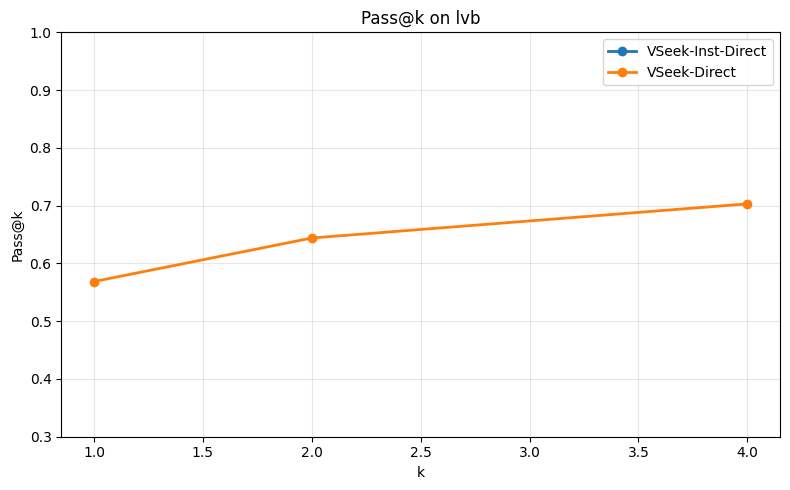

videomme


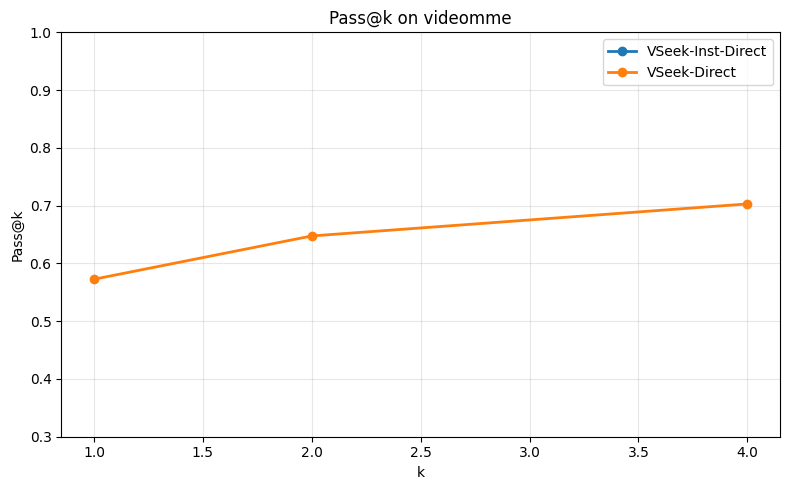

mlvu


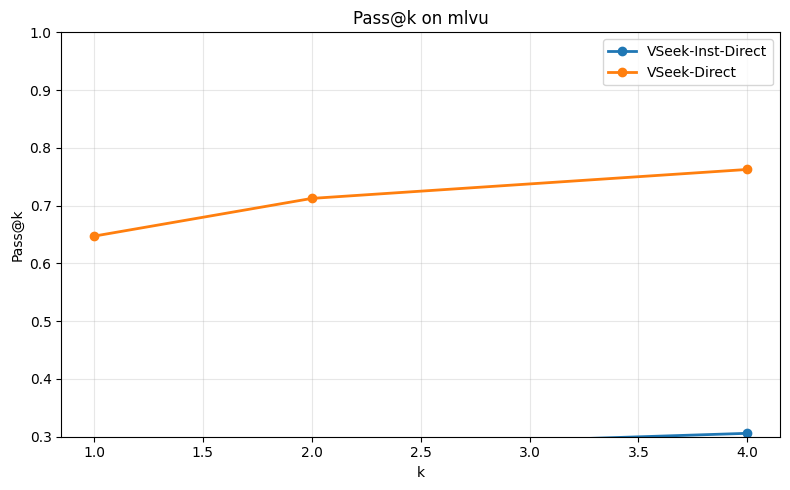

lvbench


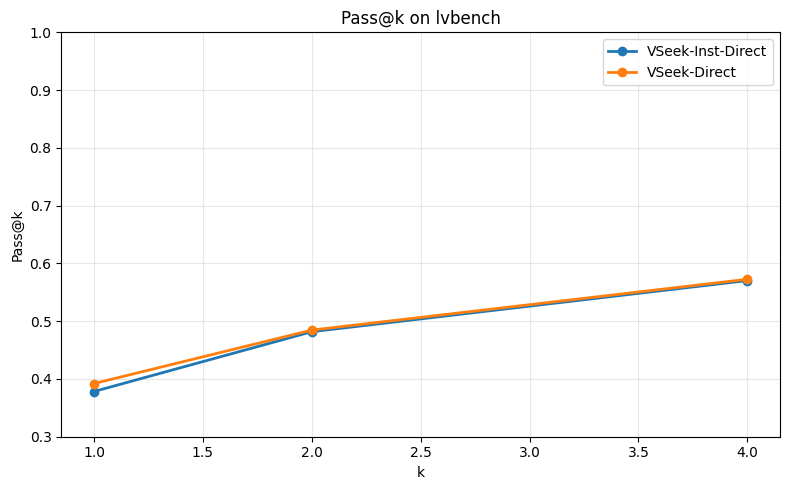

cgbench


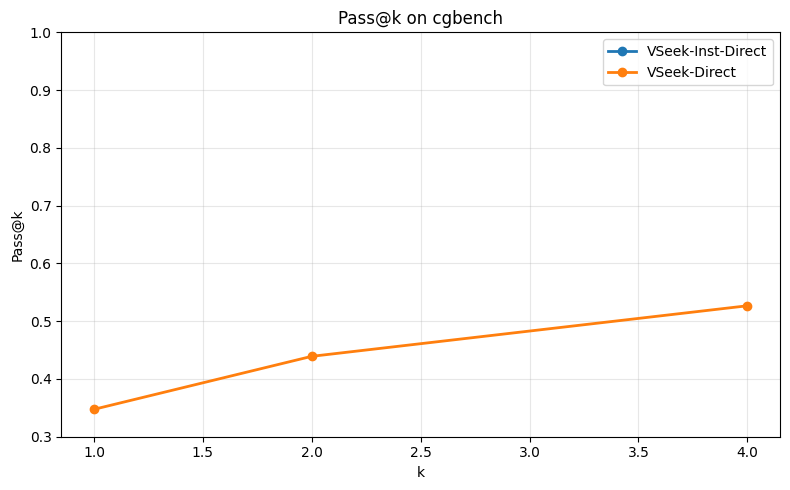

In [3]:
# PLOT DATA
for dataset, all_metrics in metrics_per_dataset.items():
    print(dataset)
    plt.figure(figsize=(8, 5))

    for name, metrics_df in all_metrics.items():
        if metrics_df.empty:
            continue
        plt.plot(metrics_df["k"], metrics_df["pass_at_k"], marker="o", linewidth=2, label=name)

    plt.title(f"Pass@k on {dataset}")
    plt.xlabel("k")
    plt.ylabel("Pass@k")
    plt.ylim(0.3, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [4]:
# MLVU original_data: duration [convert to int]
# LVBench: none (get duration from the index by metadata: video_id ->metadata.json -> frame_count)
# CGBench: original_data: duration [convert to int]
# LVB: original_data: duration [convert to int]
# VIDeomme: none (get duration from the index by metadata: video_id ->metadata.json -> frame_count) 


In [5]:
# PERFORMANCE BY VIDEO LENGTH (RULE-BASED DURATION SOURCES)
# Rules:
# - mlvu, cgbench, lvb: duration from original_data
# - lvbench, videomme: duration from index metadata (video_id -> metadata.json -> frame_count)

from collections import defaultdict
from pathlib import Path
import pandas as pd
# Optional: update if your paths differ.
DATASET_PATHS = {
    "mlvu": Path("/nas/mars/dataset/MLVU/MLVU"),
    "cgbench": Path("/nas/mars/dataset/CGBench"),
    "lvb": Path("/nas/mars/dataset/longvideobench/LongVideoBench"),
    "lvbench": Path("/nas/mars/dataset/LVBench"),
    "videomme": Path("/nas/mars/dataset/Video-MME"),
}

# Where indexed VideoFrames are stored: <INDEX_ROOT>/<dataset>_window_<WINDOW_SIZE>/<video_id>/metadata.json
INDEX_ROOT = Path("/home/hg22723/vseek/dataset")
WINDOW_SIZE = 8

# Buckets in seconds
LENGTH_BINS = [0, 60, 600, 3600, float("inf")]
LENGTH_BIN_LABELS = ["<1m", "1m-10m", "10-60m", "60m+"]
CAP_N = 4

# Report the video-length breakdown for every dataset available in this notebook.
TARGET_DATASETS = ["lvb", "videomme", "mlvu"]
METHOD_ALIASES = {
    "Uniform Thinking": ["Qwen 4B Thinking"],
    "Uniform Instruct": ["Qwen 4B Instruct"],
    "VideoTree": ["VideoTree"],
    "VideoRAG": ["VideoRAG", "Vanilla RAG"],
    "VSEEK-EM": ["VSEEK-EM", "VSeek-EM"],
    "VSEEK-PULS": ["VSEEK-PULS", "VSeek-Puls"],
    "VSEEK-GPT": ["VSEEK-GPT", "VSeek-GPT"],
}

filtered_result_files = {}
for display_name, aliases in METHOD_ALIASES.items():
    for alias in aliases:
        if alias in RESULT_FILES:
            filtered_result_files[display_name] = RESULT_FILES[alias]
            break

# Optional explicit VideoTree path if not present in RESULT_FILES.
if "VideoTree" not in filtered_result_files:
    filtered_result_files["VideoTree"] = Path("../../results/videotree/mlvu/agent_results.json")


def normalize_video_key(value) -> str:
    # s = str(value).strip()
    # s = s.split("/")[-1]
    # if "." in s:
    #     s = s.rsplit(".", 1)[0]
    return value


def find_first_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    lower_to_real = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower_to_real:
            return lower_to_real[c.lower()]
    return None


def load_json_safe(path: Path):
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def to_seconds_from_value(v):
    if v is None:
        return None
    if isinstance(v, (int, float)):
        return float(v)
    s = str(v).strip()
    if not s:
        return None
    # Numeric string
    try:
        return float(s)
    except Exception:
        pass
    # HH:MM:SS or MM:SS
    td = pd.to_timedelta(s, errors="coerce")
    if pd.notna(td):
        return float(td.total_seconds())
    return None


def extract_duration_from_original_data(item: dict) -> float | None:
    # Common keys observed across datasets
    candidates = [
        "duration", "video_duration", "duration_sec", "duration_seconds",
        "length", "video_length", "seconds"
    ]
    for k in candidates:
        if k in item:
            sec = to_seconds_from_value(item.get(k))
            if sec is not None:
                return sec
    return None



def build_duration_map_json(dataset_path: Path) -> dict[str, float]:
    out = {}
    lvb_file = dataset_path / "puls_refined.json"
    data = load_json_safe(lvb_file)
    if not isinstance(data, list):
        return out
    for item in data:
        vid = item.get("metadata").get("video_id")
        if vid is None:
            continue
        key = normalize_video_key(vid)
        sec = extract_duration_from_original_data(json.loads(item.get("metadata").get("original_data")))
        if sec is not None and key not in out:
            out[key] = sec
    return out


def build_duration_map_from_index(dataset: str, index_root: Path, window_size: int) -> dict[str, float]:
    out = {}
    root = index_root / f"{dataset}_window_{window_size}"
    if not root.exists():
        return out

    for video_dir in root.iterdir():
        if not video_dir.is_dir():
            continue
        md_path = video_dir / "metadata.json"
        if not md_path.exists():
            continue
        md = load_json_safe(md_path)
        if not isinstance(md, dict):
            continue

        # frame_count in your note; fallback to frames_count used by VideoFrames._save_hybrid
        frame_count = md.get("frame_count", md.get("frames_count"))
        fps = md.get("fps", 1)
        if frame_count is None:
            continue
        try:
            dur = float(frame_count) / float(fps)
        except Exception:
            continue

        out[normalize_video_key(video_dir.name)] = dur

    return out


def prepare_results_for_merge(df: pd.DataFrame) -> pd.DataFrame:
    id_col = find_first_column(df, ["video_id", "video", "video_uid", "vid", "video_path"])
    if id_col is None:
        raise ValueError(f"Could not infer video id column in results: {list(df.columns)}")

    out = df.copy()
    out["video_key"] = out[id_col].map(normalize_video_key)

    if "is_majority_correct" in out.columns:
        out["is_correct"] = out["is_majority_correct"].astype(float)
    else:
        out["is_correct"] = out.apply(lambda r: infer_majority_correct(r, CAP_N), axis=1).astype(float)

    return out[["video_key", "is_correct"]]


def build_duration_map(dataset: str) -> dict[str, float]:
    if dataset == "mlvu" or dataset == "lvb" or dataset == "cgbench":
        return build_duration_map_json(DATASET_PATHS[dataset])
    if dataset in {"lvbench", "videomme"}:
        return build_duration_map_from_index(dataset, INDEX_ROOT, WINDOW_SIZE)
    return {}


length_perf_rows = []
coverage_rows = []

for dataset in TARGET_DATASETS:
    duration_map = build_duration_map(dataset)
    if not duration_map:
        print(f"[skip] No durations found for dataset: {dataset}")
        continue

    dur_df = pd.DataFrame({
        "video_key": list(duration_map.keys()),
        "video_length_sec": list(duration_map.values()),
    })
    dur_df["length_bucket"] = pd.cut(
        dur_df["video_length_sec"],
        bins=LENGTH_BINS,
        labels=LENGTH_BIN_LABELS,
        right=False,
        include_lowest=True,
    )

    for method, path in filtered_result_files.items():
        result_path = Path(str(path).replace("mlvu", dataset))
        if not result_path.exists():
            continue

        result_df = load_jsonl(result_path) if ".jsonl" in str(result_path) else load_json(result_path)
        result_df = maybe_repair_dataframe_predictions(result_df, method)

        try:
            res_prepared = prepare_results_for_merge(result_df)
        except Exception as exc:
            print(f"[skip] Results parse failed ({dataset}, {method}): {exc}")
            continue

        merged = res_prepared.merge(dur_df, on="video_key", how="inner")
        coverage_rows.append({
            "dataset": dataset,
            "method": method,
            "matched_questions": int(len(merged)),
            "total_questions": int(len(res_prepared)),
            "coverage": float(len(merged) / max(len(res_prepared), 1)),
        })

        if merged.empty:
            continue

        agg = (
            merged.groupby("length_bucket", observed=True)["is_correct"]
            .agg(["mean", "count"])
            .reset_index()
            .rename(columns={"mean": "accuracy", "count": "num_questions"})
        )
        agg["dataset"] = dataset
        agg["method"] = method
        length_perf_rows.append(agg)


if not length_perf_rows:
    raise RuntimeError("No rows were produced. Verify DATASET_PATHS/INDEX_ROOT and duration keys in source data.")

length_perf_df = pd.concat(length_perf_rows, ignore_index=True)
length_perf_df["length_bucket"] = pd.Categorical(
    length_perf_df["length_bucket"], categories=LENGTH_BIN_LABELS, ordered=True
)
length_perf_df = length_perf_df.sort_values(["dataset", "length_bucket", "method"]).reset_index(drop=True)
coverage_df = pd.DataFrame(coverage_rows)

print("Merge coverage:")
display(coverage_df.sort_values(["dataset", "method"]))

print("Bucketed accuracy:")
display(length_perf_df)

for dataset in TARGET_DATASETS:
    subset = length_perf_df[length_perf_df["dataset"] == dataset].copy()
    if subset.empty:
        continue

    subset["length_bucket"] = pd.Categorical(
        subset["length_bucket"], categories=LENGTH_BIN_LABELS, ordered=True
    )
    subset = subset.sort_values("length_bucket")

    pivot = subset.pivot(index="length_bucket", columns="method", values="accuracy")
    count_pivot = subset.pivot(index="length_bucket", columns="method", values="num_questions")

    # Report numeric values in addition to plots.
    pivot = pivot.reindex(LENGTH_BIN_LABELS)
    count_pivot = count_pivot.reindex(LENGTH_BIN_LABELS)
    pivot_rounded = pivot.round(4)
    count_pivot_filled = count_pivot.fillna(0).astype(int)

    print(f"Numeric accuracy by length ({dataset}):")
    display(pivot_rounded)
    print(f"Question counts by length ({dataset}):")
    display(count_pivot_filled)
    print(f"Per-bucket performance ({dataset}):")
    for bucket in LENGTH_BIN_LABELS:
        row_scores = pivot_rounded.loc[bucket].dropna() if bucket in pivot_rounded.index else pd.Series(dtype=float)
        row_counts = count_pivot_filled.loc[bucket] if bucket in count_pivot_filled.index else pd.Series(dtype=int)
        if row_scores.empty:
            continue
        metrics = ", ".join(
            f"{method}={score:.4f} (n={int(row_counts.get(method, 0))})"
            for method, score in row_scores.items()
        )
        print(f"  {bucket}: {metrics}")

    ax = pivot.plot(kind="bar", figsize=(11, 5), width=0.85)
    ax.set_title(f"Majority Accuracy by Video Length ({dataset})")
    ax.set_xlabel("Video length bucket")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.0, 1.0)
    ax.grid(axis="y", alpha=0.3)
    plt.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

RuntimeError: No rows were produced. Verify DATASET_PATHS/INDEX_ROOT and duration keys in source data.

In [ ]:
# Deprecated: replaced by the rules-based duration cell above.
# Keep this cell empty to avoid mixing two metadata pipelines.
pass

In [ ]:
# FRAME USAGE ESTIMATES
# 1) VSeek-EM / VSeek-Puls: estimated_frames = ((max(turns) / 2) - 1) * 16
# 2) VSeek-GPT: use conversation tool returns in pred[*] (sum of image_count)

import json
from pathlib import Path
import pandas as pd

RESULT_ROOT = Path("../../results/vseek")
TURN_METHOD_DIRS = {
    "VSeek-EM": RESULT_ROOT / "vseek",
    "VSeek-Puls": RESULT_ROOT / "vseek-puls",
}
GPT_DIR = RESULT_ROOT / "gpt"

def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

turn_rows = []
for method, method_dir in TURN_METHOD_DIRS.items():
    for file_path in sorted(method_dir.glob("*/agent_results.jsonl")):
        dataset = file_path.parent.name
        data = load_jsonl(file_path)

        max_turns = []
        missing_turns = 0
        for item in data:
            turns = item.get("turns")
            if not isinstance(turns, list) or not turns:
                missing_turns += 1
                continue
            turn_vals = []
            for t in turns:
                try:
                    turn_vals.append(float(t))
                except Exception:
                    pass
            if not turn_vals:
                missing_turns += 1
                continue
            max_turns.append(max(turn_vals))

        if not max_turns:
            continue

        est_frames = [((mt / 2.0) - 1.0) * 16.0 for mt in max_turns]
        turn_rows.append({
            "method": method,
            "dataset": dataset,
            "n": len(max_turns),
            "missing_turns": missing_turns,
            "avg_max_turn": float(pd.Series(max_turns).mean()),
            "median_max_turn": float(pd.Series(max_turns).median()),
            "avg_est_frames": float(pd.Series(est_frames).mean()),
            "median_est_frames": float(pd.Series(est_frames).median()),
        })

turn_frame_df = pd.DataFrame(turn_rows)
if turn_frame_df.empty:
    print("VSeek-EM / VSeek-Puls: no rows — check RESULT_ROOT and TURN_METHOD_DIRS (expect …/vseek/*/agent_results.jsonl).")
else:
    turn_frame_df = turn_frame_df.sort_values(["method", "dataset"]).reset_index(drop=True)
print("VSeek-EM / VSeek-Puls (turn-based estimate):")
display(turn_frame_df)

turn_overall_rows = []
if not turn_frame_df.empty:
    for method, g in turn_frame_df.groupby("method"):
        n_total = int(g["n"].sum())
        turn_overall_rows.append({
            "method": method,
            "n": n_total,
            "avg_max_turn_weighted": float((g["avg_max_turn"] * g["n"]).sum() / n_total),
            "avg_est_frames_weighted": float((g["avg_est_frames"] * g["n"]).sum() / n_total),
        })
turn_overall_df = pd.DataFrame(turn_overall_rows)
if not turn_overall_df.empty:
    turn_overall_df = turn_overall_df.sort_values("method").reset_index(drop=True)
print("Overall (weighted by dataset size):")
display(turn_overall_df)

# ---- VSeek-GPT from pred conversations ----
import re
win_pat = re.compile(r"window_indices=\[([^\]]*)\]")

gpt_rows = []
for file_path in sorted(GPT_DIR.glob("*/agent_results.json")):
    dataset = file_path.parent.name
    data = json.loads(file_path.read_text(encoding="utf-8"))
    if not isinstance(data, list) or not data:
        continue

    frames_per_q = []
    calls_per_q = []
    unique_windows_per_q = []

    for item in data:
        pred = item.get("pred", [])
        q_frames = []
        q_calls = 0
        q_windows = set()

        if isinstance(pred, list):
            for pass_conv in pred:
                frame_count = 0
                if not isinstance(pass_conv, list):
                    continue
                for msg in pass_conv:
                    if not isinstance(msg, dict):
                        continue
                    ctext = msg.get("content_text", "")
                    if isinstance(ctext, str) and ctext.startswith("External tool result from retriever server."):
                        q_calls += 1
                        img_count = msg.get("image_count", 0)
                        if isinstance(img_count, (int, float)):
                            frame_count += int(img_count)
                        m = win_pat.search(ctext)
                        if m:
                            body = m.group(1).strip()
                            if body:
                                for p in body.split(","):
                                    p = p.strip()
                                    try:
                                        q_windows.add(int(p))
                                    except Exception:
                                        pass
                q_frames.append(frame_count)
        q_frames = max(q_frames) if q_frames else 0

        frames_per_q.append(q_frames)
        calls_per_q.append(q_calls)
        unique_windows_per_q.append(len(q_windows))

    gpt_rows.append({
        "method": "VSeek-GPT",
        "dataset": dataset,
        "n": len(data),
        "avg_tool_calls_per_q": float(pd.Series(calls_per_q).mean()),
        "avg_frames_per_q": float(pd.Series(frames_per_q).mean()),
        "median_frames_per_q": float(pd.Series(frames_per_q).median()),
        "avg_unique_window_indices_per_q": float(pd.Series(unique_windows_per_q).mean()),
    })

gpt_frame_df = pd.DataFrame(gpt_rows)
if gpt_frame_df.empty:
    print(f"VSeek-GPT: no rows — no agent_results.json under GPT_DIR: {GPT_DIR}")
else:
    gpt_frame_df = gpt_frame_df.sort_values("dataset").reset_index(drop=True)
print("VSeek-GPT (from pred conversations):")
display(gpt_frame_df)

if not gpt_frame_df.empty:
    n_total = int(gpt_frame_df["n"].sum())
    gpt_overall_df = pd.DataFrame([{
        "method": "VSeek-GPT",
        "n": n_total,
        "avg_tool_calls_per_q_weighted": float((gpt_frame_df["avg_tool_calls_per_q"] * gpt_frame_df["n"]).sum() / n_total),
        "avg_frames_per_q_weighted": float((gpt_frame_df["avg_frames_per_q"] * gpt_frame_df["n"]).sum() / n_total),
        "avg_unique_window_indices_per_q_weighted": float((gpt_frame_df["avg_unique_window_indices_per_q"] * gpt_frame_df["n"]).sum() / n_total),
    }])
    print("VSeek-GPT overall (weighted by dataset size):")
    display(gpt_overall_df)

# ---- Average frames retrieved per video size bucket ----
if "build_duration_map" not in globals():
    raise RuntimeError("build_duration_map is not defined. Please run the video-length analysis cell first.")

def normalize_video_id(v):
    return normalize_video_key(v) if "normalize_video_key" in globals() else str(v)

frame_rows = []

# VSeek-EM / VSeek-Puls from turns
for method, method_dir in TURN_METHOD_DIRS.items():
    for file_path in sorted(method_dir.glob("*/agent_results.jsonl")):
        dataset = file_path.parent.name
        data = load_jsonl(file_path)
        for item in data:
            turns = item.get("turns")
            if not isinstance(turns, list) or not turns:
                continue
            turn_vals = []
            for t in turns:
                try:
                    turn_vals.append(float(t))
                except Exception:
                    pass
            if not turn_vals:
                continue
            max_turn = max(turn_vals)
            est_frames = ((max_turn / 2.0) - 1.0) * 16.0
            frame_rows.append({
                "method": method,
                "dataset": dataset,
                "video_key": normalize_video_id(item.get("video_id")),
                "frames_retrieved": float(est_frames),
            })

# VSeek-GPT from pred conversations
for file_path in sorted(GPT_DIR.glob("*/agent_results.json")):
    dataset = file_path.parent.name
    data = json.loads(file_path.read_text(encoding="utf-8"))
    if not isinstance(data, list):
        continue
    for item in data:
        pred = item.get("pred", [])
        q_frames = []
        if isinstance(pred, list):
            
            for pass_conv in pred:
                count_frames = 0
                if not isinstance(pass_conv, list):
                    continue
                for msg in pass_conv:
                    if not isinstance(msg, dict):
                        continue
                    ctext = msg.get("content_text", "")
                    if isinstance(ctext, str) and ctext.startswith("External tool result from retriever server."):
                        img_count = msg.get("image_count", 0)
                        if isinstance(img_count, (int, float)):
                            count_frames += int(img_count)
                q_frames.append(count_frames)
        q_frames = max(q_frames) if q_frames else 0
        frame_rows.append({
            "method": "VSeek-GPT",
            "dataset": dataset,
            "video_key": normalize_video_id(item.get("video_id")),
            "frames_retrieved": float(q_frames),
        })

frame_df = pd.DataFrame(frame_rows)
if frame_df.empty:
    raise RuntimeError("No frame-usage rows produced.")

bucket_rows = []
target_datasets_for_bucket = ["lvb", "videomme", "mlvu", "lvbench", "cgbench"]
for dataset in target_datasets_for_bucket:
    duration_map = build_duration_map(dataset)
    if not duration_map:
        continue
    dur_df = pd.DataFrame({
        "video_key": list(duration_map.keys()),
        "video_length_sec": list(duration_map.values()),
    })
    dur_df["length_bucket"] = pd.cut(
        dur_df["video_length_sec"],
        bins=LENGTH_BINS,
        labels=LENGTH_BIN_LABELS,
        right=False,
        include_lowest=True,
    )

    fsub = frame_df[frame_df["dataset"] == dataset]
    if fsub.empty:
        continue
    merged = fsub.merge(dur_df, on="video_key", how="inner")
    if merged.empty:
        continue
    agg = (
        merged.groupby(["dataset", "method", "length_bucket"], observed=True)["frames_retrieved"]
        .agg(["mean", "median", "count"])
        .reset_index()
        .rename(columns={"mean": "avg_frames_retrieved", "median": "median_frames_retrieved", "count": "num_questions"})
    )
    bucket_rows.append(agg)

if not bucket_rows:
    raise RuntimeError("No bucketed frame-usage rows produced.")

bucket_df = pd.concat(bucket_rows, ignore_index=True)
bucket_df["length_bucket"] = pd.Categorical(bucket_df["length_bucket"], categories=LENGTH_BIN_LABELS, ordered=True)
bucket_df = bucket_df.sort_values(["dataset", "length_bucket", "method"]).reset_index(drop=True)

print("Average frames retrieved per video size bucket:")
display(bucket_df)

for dataset in target_datasets_for_bucket:
    dsub = bucket_df[bucket_df["dataset"] == dataset]
    if dsub.empty:
        continue
    print(f"Pivot (avg frames) for {dataset}:")
    pivot = dsub.pivot(index="length_bucket", columns="method", values="avg_frames_retrieved").reindex(LENGTH_BIN_LABELS)
    display(pivot.round(2))